# Learning analysis for intermediate positions

In [1]:
import os
import chess
import chess.engine
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob
import re

In [2]:
# Increase font size a bit
plt.rcParams.update({'font.size': 16})

## Function definitions

In [3]:
def get_ordered_unique_values(a):
    x,c = np.unique(a,return_counts=True)
    x = x[np.argsort(c)[::-1]]
    c = np.sort(c)[::-1]
    return x,c

In [4]:
def get_mean_and_sem(x):
    return np.nanmean(x),np.nanstd(x)/np.sqrt(len(x))

In [5]:
def load_csv_folder(folder_path: str) -> list:
    files = sorted(glob.glob(f"{folder_path}/*.csv"), key=lambda f: int(re.search(r'job_(\d+)', f).group(1)))
    return (-pd.concat([pd.read_csv(f, header=None) for f in files])[0]).tolist()

## Queen's Gambit

In [6]:
# Load the csv data of QG games (October 2020 - March 2021)
direc = '../../Data/Learning/queens_gambit/'

df = pd.concat([pd.read_csv(direc + 'intermediate_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','fourthmove','move5'])
                for j in range(9,15)],ignore_index=True)

In [7]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'QG_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

In [8]:
# Add accept, decline (either the Slav Defense or QG Declined), other to df
df['fourthcode'] = df['fourthmove'].map({'d5c4' : 'A', 'e7e6' : 'D', 'c7c6' : 'D'}).fillna('O')

# Add move index to df
unique_fourthmoves,_ = get_ordered_unique_values(df['fourthmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_fourthmoves)}
df['fourthindex'] = np.array([move_to_index[m] for m in df['fourthmove'].astype(str)])

In [9]:
# View the remaining data
df

,black,white,result,fourthmove,move5,fourthcode,fourthindex
0,Ashakiran,codnjk,0.0,c7c6,rnbq1rk1/pp3ppp/2p1pn2/3p4/2PP1B2/P1P2N2/4PPPP...,D,3
1,Jimbobnc,Future_Star,1.0,c7c5,rnb1kb1r/pp3ppp/5p2/8/2pq4/2N1P3/PP3PPP/R3KBNR...,O,6
2,salahflah,lewisp,1.0,d5c4,rnbqk2r/2p2ppp/p2bpn2/1p6/2pPPB2/2N2N2/PPQ2PPP...,A,0
3,CatzorYum,levonhardt,0.0,d5c4,NaN,A,0
4,kingdrelpins,shahmizad,1.0,c7c6,rn1qkb1r/pp2ppp1/2p5/3n4/3P2p1/2N5/PP2PPPP/R1B...,D,3
...,...,...,...,...,...,...,...
831330,BySmoot,jruiz10,0.0,d5c4,rnbqk2r/pp3ppp/2p1p3/3nP3/1bBP4/5Q1N/PP3PPP/RN...,A,0
831331,JDG9234,Sisyfos75,1.0,d5c4,r1bqkbnr/pp3ppp/4p3/8/2Bn1B2/4P3/PP3PPP/RN1QK2...,A,0
831332,CuzcoMaria17,BlacKing64,1.0,d5c4,rn1qk2r/ppp2ppp/4pn2/7b/1bBPP3/2N2P2/PP2N1PP/R...,A,0
831333,florinarnautu,CorporalRivalle,1.0,g8f6,r1bqkb1r/ppp2ppp/5n2/4n3/2pP4/2N1P1P1/PP3P1P/R...,O,2


In [10]:
# Load the intermediate evalutions
results_path = '../evaluate-positions/queens_gambit/'
intermediate_res = load_csv_folder(results_path)

In [11]:
# Add the intermediate evaluations to the dataframe
df['move5'] = intermediate_res
df

,black,white,result,fourthmove,move5,fourthcode,fourthindex
0,Ashakiran,codnjk,0.0,c7c6,67.0,D,3
1,Jimbobnc,Future_Star,1.0,c7c5,-93.0,O,6
2,salahflah,lewisp,1.0,d5c4,341.0,A,0
3,CatzorYum,levonhardt,0.0,d5c4,NaN,A,0
4,kingdrelpins,shahmizad,1.0,c7c6,181.0,D,3
...,...,...,...,...,...,...,...
831330,BySmoot,jruiz10,0.0,d5c4,35.0,A,0
831331,JDG9234,Sisyfos75,1.0,d5c4,4.0,A,0
831332,CuzcoMaria17,BlacKing64,1.0,d5c4,334.0,A,0
831333,florinarnautu,CorporalRivalle,1.0,g8f6,-12.0,O,2


In [12]:
# Filter out players who have played the QG in this period
df = df[df['black'].apply(lambda p: not p in s)].reset_index(drop=True)
df

,black,white,result,fourthmove,move5,fourthcode,fourthindex
0,Jimbobnc,Future_Star,1.0,c7c5,-93.0,O,6
1,Hosain_alsaadi,KhaXIIIled_13,0.0,g8f6,85.0,O,2
2,PekeCatriel,allangargamel,1.0,c7c6,1100.0,D,3
3,victorhugocueto,FlashGilmore,1.0,c7c6,60.0,D,3
4,hatemylife987987,codnjk,1.0,g8f6,371.0,O,2
...,...,...,...,...,...,...,...
691232,BySmoot,jruiz10,0.0,d5c4,35.0,A,0
691233,JDG9234,Sisyfos75,1.0,d5c4,4.0,A,0
691234,CuzcoMaria17,BlacKing64,1.0,d5c4,334.0,A,0
691235,florinarnautu,CorporalRivalle,1.0,g8f6,-12.0,O,2


In [13]:
# Create a binary dataframe of just accept/decline
df_binary = df[(df['fourthcode'].isin(['A','D'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['black'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,fourthmove,move5,fourthcode,fourthindex
0,PekeCatriel,allangargamel,1.0,c7c6,1100.0,D,3
1,victorhugocueto,FlashGilmore,1.0,c7c6,60.0,D,3
2,followill8,HelloTheSecond,1.0,c7c6,-20.0,D,3
3,justben,ozgurwilly,0.0,d5c4,289.0,A,0
4,followill8,bellatrix111,1.0,c7c6,103.0,D,3
...,...,...,...,...,...,...,...
480927,sartanc,blindspott,0.0,d5c4,146.0,A,0
480928,BySmoot,jruiz10,0.0,d5c4,35.0,A,0
480929,JDG9234,Sisyfos75,1.0,d5c4,4.0,A,0
480930,CuzcoMaria17,BlacKing64,1.0,d5c4,334.0,A,0


In [14]:
# Compute the index of the last game as black/white for each QG game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['black']]
    last_game_as_black[i] = d_black[row['black']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0
100000
200000
300000
400000


In [15]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,fourthmove,move5,fourthcode,fourthindex,last_game_as_white,last_game_as_black
0,PekeCatriel,allangargamel,1.0,c7c6,1100.0,D,3,-1,-1
1,victorhugocueto,FlashGilmore,1.0,c7c6,60.0,D,3,-1,-1
2,followill8,HelloTheSecond,1.0,c7c6,-20.0,D,3,-1,-1
3,justben,ozgurwilly,0.0,d5c4,289.0,A,0,-1,-1
4,followill8,bellatrix111,1.0,c7c6,103.0,D,3,-1,2
...,...,...,...,...,...,...,...,...,...
480927,sartanc,blindspott,0.0,d5c4,146.0,A,0,-1,480908
480928,BySmoot,jruiz10,0.0,d5c4,35.0,A,0,-1,-1
480929,JDG9234,Sisyfos75,1.0,d5c4,4.0,A,0,-1,401683
480930,CuzcoMaria17,BlacKing64,1.0,d5c4,334.0,A,0,-1,-1


In [16]:
# Compute probability of repetition as a function of intermediate evaluation for the QG
game_eval = df_binary['move5'].values
code = df_binary['fourthcode'].values
eval_range = np.arange(-500,500,200)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_black']) 
                           if iprev>=0 and game_eval[iprev]>=evaluation and game_eval[iprev]<evaluation+200]) for evaluation in eval_range]

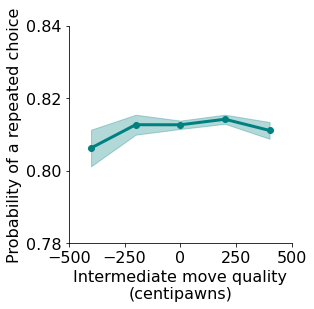

In [18]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(eval_range+100, [m for m,s in means], marker='o', color='teal', lw=3)
ax.fill_between(eval_range+100, [m-s for m,s in means], [m+s for m,s in means], color='teal', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Intermediate move quality\n(centipawns)')
ax.set_xticks([-500,-250,0,250,500])
ax.set_yticks([0.78,0.8,0.82,0.84])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_intermediate.png', format='png', dpi=1000,bbox_inches = 'tight')

## Sicilian Defense

In [19]:
# Load the csv data of SD games (October 2020 - March 2021)
direc = '../../Data/Learning/sicilian_defense/'

df = pd.concat([pd.read_csv(direc + 'intermediate_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','thirdmove','move5'])
                for j in range(9,15)],ignore_index=True)

In [20]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'SD_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

In [21]:
# Add closed, open, or else to df
df['thirdcode'] = df['thirdmove'].map({'b1c3' : 'C', 'g1f3' : 'O'}).fillna('E')

# Add move index to df
unique_thirdmoves,_ = get_ordered_unique_values(df['thirdmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_thirdmoves)}
df['thirdindex'] = np.array([move_to_index[m] for m in df['thirdmove'].astype(str)])

In [22]:
# View the remaining data
df

,black,white,result,thirdmove,move5,thirdcode,thirdindex
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,r1bqk2r/pp2bppp/2nppn2/1Bp5/4PP2/2N2N2/PPPP2PP...,C,3
1,antonbovensmann,bob_fisher2026,1.0,g1f3,r1bqkb1r/p2ppppp/1p3n2/8/3QP3/2N1B3/PPP2PPP/R3...,O,0
2,Raptorax,larspli,1.0,d2d4,rnb1kbnr/1p1p1ppp/p3p3/8/4P3/1NN1B3/PqP2PPP/R2...,E,2
3,srivijay96,jonathan7291,0.0,f1c4,r1bqkb1r/pp1p1ppp/4p3/2p5/1nB1n3/N2P1N1Q/PPP2P...,E,1
4,jy3,Scratchman,0.0,g1f3,r1bqkb1r/ppn1pppp/5n2/2pP4/2B5/2PP1N2/PP3PPP/R...,O,0
...,...,...,...,...,...,...,...
1739409,DawsonRicardo,aruniyer88,1.0,g1f3,NaN,O,0
1739410,Greyuta,Moi555,0.0,a2a3,r1bqkb1r/p2pn1pp/1pn2p2/2p1p2Q/2B1P3/P1N5/1PPP...,E,15
1739411,Powder36,phildeacon,0.0,d1h5,r1bqk2r/pp1pnpbp/2n1p1p1/2p5/2P1P3/3P1Q2/PPB2P...,E,4
1739412,Arteaga1811,Kh0nsu,1.0,g1f3,r1bqkb1r/pp1p2pp/2n1pP2/2p3B1/6n1/2NP1N2/PPP2P...,O,0


In [23]:
# Load the intermediate evalutions
results_path = '../evaluate-positions/sicilian_defense/'
intermediate_res = load_csv_folder(results_path)

In [24]:
# Add the intermediate evaluations to the dataframe
df['move5'] = intermediate_res
df

,black,white,result,thirdmove,move5,thirdcode,thirdindex
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,-49.0,C,3
1,antonbovensmann,bob_fisher2026,1.0,g1f3,-191.0,O,0
2,Raptorax,larspli,1.0,d2d4,874.0,E,2
3,srivijay96,jonathan7291,0.0,f1c4,289.0,E,1
4,jy3,Scratchman,0.0,g1f3,-103.0,O,0
...,...,...,...,...,...,...,...
1739409,DawsonRicardo,aruniyer88,1.0,g1f3,NaN,O,0
1739410,Greyuta,Moi555,0.0,a2a3,-166.0,E,15
1739411,Powder36,phildeacon,0.0,d1h5,193.0,E,4
1739412,Arteaga1811,Kh0nsu,1.0,g1f3,48.0,O,0


In [25]:
# Filter out players who have played the SD in this period
df = df[df['white'].apply(lambda p: not p in s)].reset_index(drop=True)
df

,black,white,result,thirdmove,move5,thirdcode,thirdindex
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,-49.0,C,3
1,jy3,Scratchman,0.0,g1f3,-103.0,O,0
2,spitecheck,zralybokyma,0.0,f1b5,-147.0,E,12
3,dermaxe,Pandi9595,1.0,b1c3,-99.0,C,3
4,duliomarcio,Raptorax,0.0,g1f3,-102.0,O,0
...,...,...,...,...,...,...,...
1406939,DawsonRicardo,aruniyer88,1.0,g1f3,NaN,O,0
1406940,Greyuta,Moi555,0.0,a2a3,-166.0,E,15
1406941,Powder36,phildeacon,0.0,d1h5,193.0,E,4
1406942,Arteaga1811,Kh0nsu,1.0,g1f3,48.0,O,0


In [26]:
# Create a binary dataframe of just closed/open
df_binary = df[(df['thirdcode'].isin(['C','O'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['white'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,thirdmove,move5,thirdcode,thirdindex
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,-49.0,C,3
1,jy3,Scratchman,0.0,g1f3,-103.0,O,0
2,dermaxe,Pandi9595,1.0,b1c3,-99.0,C,3
3,duliomarcio,Raptorax,0.0,g1f3,-102.0,O,0
4,cris15chess2020,AdrianHR2020,1.0,g1f3,-22.0,O,0
...,...,...,...,...,...,...,...
714213,Dancheco,jamin34,1.0,g1f3,149.0,O,0
714214,Animal-pant,TarumarRiayet,1.0,g1f3,40.0,O,0
714215,DawsonRicardo,aruniyer88,1.0,g1f3,NaN,O,0
714216,Arteaga1811,Kh0nsu,1.0,g1f3,48.0,O,0


In [27]:
# Compute the index of the last game as black/white for each SD game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['white']]
    last_game_as_black[i] = d_black[row['white']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0
100000
200000
300000
400000
500000
600000
700000


In [28]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,thirdmove,move5,thirdcode,thirdindex,last_game_as_white,last_game_as_black
0,Kami_of_Honmaru,wonderingblunder,1.0,b1c3,-49.0,C,3,-1,-1
1,jy3,Scratchman,0.0,g1f3,-103.0,O,0,-1,-1
2,dermaxe,Pandi9595,1.0,b1c3,-99.0,C,3,-1,-1
3,duliomarcio,Raptorax,0.0,g1f3,-102.0,O,0,-1,-1
4,cris15chess2020,AdrianHR2020,1.0,g1f3,-22.0,O,0,-1,-1
...,...,...,...,...,...,...,...,...,...
714213,Dancheco,jamin34,1.0,g1f3,149.0,O,0,714199,545842
714214,Animal-pant,TarumarRiayet,1.0,g1f3,40.0,O,0,713090,713137
714215,DawsonRicardo,aruniyer88,1.0,g1f3,NaN,O,0,689858,-1
714216,Arteaga1811,Kh0nsu,1.0,g1f3,48.0,O,0,698226,-1


In [29]:
# Compute probability of repetition as a function of intermediate evaluation for the SD
game_eval = df_binary['move5'].values
code = df_binary['thirdcode'].values
eval_range = np.arange(-500,500,200)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and game_eval[iprev]>=evaluation and game_eval[iprev]<evaluation+200]) for evaluation in eval_range]

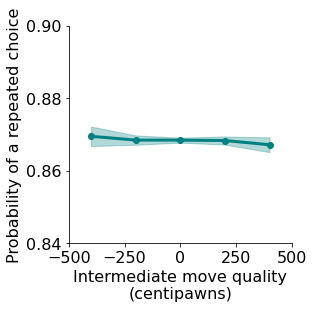

In [31]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(eval_range+100, [m for m,s in means], marker='o', color='teal', lw=3)
ax.fill_between(eval_range+100, [m-s for m,s in means], [m+s for m,s in means], color='teal', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Intermediate move quality\n(centipawns)')
ax.set_xticks([-500,-250,0,250,500])
ax.set_yticks([0.84,0.86,0.88,0.9])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_intermediate.png', format='png', dpi=1000,bbox_inches = 'tight')

## Kings Knight

In [32]:
# Load the csv data of KK games (October 2020 - March 2021)
direc = '../../Data/Learning/kings_knight/'

df = pd.concat([pd.read_csv(direc + 'length_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','fifthmove','game_length'])
                for j in range(9,15)],ignore_index=True)

In [33]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'KK_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

In [34]:
# Add italian, ruy lopez, or other to df
df['fifthcode'] = df['fifthmove'].map({'f1c4' : 'I', 'f1b5' : 'R'}).fillna('O')

# Add move index to df
unique_fifthmoves,_ = get_ordered_unique_values(df['fifthmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_fifthmoves)}
df['fifthindex'] = np.array([move_to_index[m] for m in df['fifthmove'].astype(str)])

In [35]:
# View the remaining data
df

,black,white,result,fifthmove,game_length,fifthcode,fifthindex
0,jt125845,LudoMax,1.0,d2d3,75,O,5
1,ShivamKKumar,mamaboss,1.0,b1c3,17,O,1
2,DerMichi,cessax,1.0,f1c4,63,I,0
3,pelllaeon,ShockNelas113,0.0,c2c3,30,O,4
4,zorjac,ribeirojuan,0.5,f1b5,93,R,2
...,...,...,...,...,...,...,...
2795506,Senku_virtuose,Me4kata,1.0,f1c4,15,I,0
2795507,M2nero,deviengeorge,0.0,f1b5,40,R,2
2795508,TheGeneralZod,xuny,1.0,b1c3,12,O,1
2795509,waggledook,PLVST_Music,1.0,c2c3,117,O,4


In [36]:
# Load the intermediate evalutions
results_path = '../evaluate-positions/kings_knight/'
intermediate_res = load_csv_folder(results_path)

In [37]:
# Add the intermediate evaluations to the dataframe
df['move5'] = intermediate_res
df

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,move5
0,jt125845,LudoMax,1.0,d2d3,75,O,5,251.0
1,ShivamKKumar,mamaboss,1.0,b1c3,17,O,1,-626.0
2,DerMichi,cessax,1.0,f1c4,63,I,0,6.0
3,pelllaeon,ShockNelas113,0.0,c2c3,30,O,4,398.0
4,zorjac,ribeirojuan,0.5,f1b5,93,R,2,257.0
...,...,...,...,...,...,...,...,...
2795506,Senku_virtuose,Me4kata,1.0,f1c4,15,I,0,-100000.0
2795507,M2nero,deviengeorge,0.0,f1b5,40,R,2,15.0
2795508,TheGeneralZod,xuny,1.0,b1c3,12,O,1,NaN
2795509,waggledook,PLVST_Music,1.0,c2c3,117,O,4,-96.0


In [38]:
# Filter out players who have played the KK in this period
df = df[df['white'].apply(lambda p: not p in s)].reset_index(drop=True)

In [39]:
# Create a binary dataframe of just italian/ruy lopez
df_binary = df[(df['fifthcode'].isin(['I','R'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['white'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,move5
0,RIFQIPEBRIAN123,Daniel_Kundera,0.0,f1c4,34,I,0,-63.0
1,Vikingo2001,oldmangrayshirt,1.0,f1c4,25,I,0,-10.0
2,DobbsNZ,gantulg,1.0,f1b5,47,R,2,-342.0
3,f1gn2r,AhmedEinstein,0.0,f1c4,66,I,0,-149.0
4,KnowUrSelf,RSTD2006,1.0,f1c4,75,I,0,64.0
...,...,...,...,...,...,...,...,...
1225905,saani3620,DrewReallyDo,1.0,f1c4,29,I,0,-206.0
1225906,Panfi,rsastre,0.0,f1b5,70,R,2,136.0
1225907,Senku_virtuose,Me4kata,1.0,f1c4,15,I,0,-100000.0
1225908,M2nero,deviengeorge,0.0,f1b5,40,R,2,15.0


In [40]:
# Compute the index of the last game as black/white for each KK game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['white']]
    last_game_as_black[i] = d_black[row['white']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000


In [41]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,move5,last_game_as_white,last_game_as_black
0,RIFQIPEBRIAN123,Daniel_Kundera,0.0,f1c4,34,I,0,-63.0,-1,-1
1,Vikingo2001,oldmangrayshirt,1.0,f1c4,25,I,0,-10.0,-1,-1
2,DobbsNZ,gantulg,1.0,f1b5,47,R,2,-342.0,-1,-1
3,f1gn2r,AhmedEinstein,0.0,f1c4,66,I,0,-149.0,-1,-1
4,KnowUrSelf,RSTD2006,1.0,f1c4,75,I,0,64.0,-1,-1
...,...,...,...,...,...,...,...,...,...,...
1225905,saani3620,DrewReallyDo,1.0,f1c4,29,I,0,-206.0,1225340,1185551
1225906,Panfi,rsastre,0.0,f1b5,70,R,2,136.0,1225187,-1
1225907,Senku_virtuose,Me4kata,1.0,f1c4,15,I,0,-100000.0,1225807,1225571
1225908,M2nero,deviengeorge,0.0,f1b5,40,R,2,15.0,-1,-1


In [42]:
# Compute probability of repetition as a function of intermediate evaluation for the SD
game_eval = df_binary['move5'].values
code = df_binary['fifthcode'].values
eval_range = np.arange(-500,500,200)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and game_eval[iprev]>=evaluation and game_eval[iprev]<evaluation+200]) for evaluation in eval_range]

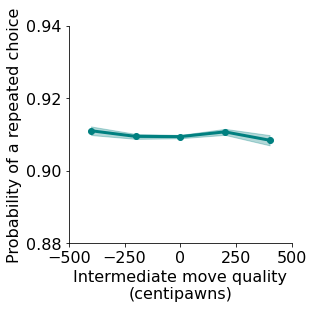

In [44]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(eval_range+100, [m for m,s in means], marker='o', color='teal', lw=3)
ax.fill_between(eval_range+100, [m-s for m,s in means], [m+s for m,s in means], color='teal', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Intermediate move quality\n(centipawns)')
ax.set_xticks([-500,-250,0,250,500])
ax.set_yticks([0.88,0.90,0.92,0.94])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_intermediate.png', format='png', dpi=1000,bbox_inches = 'tight')

## Caro-Kann Defense

In [57]:
# Load the csv data of CK games (October 2020 - March 2021)
direc = '../../Data/Learning/caro_kann/'

df = pd.concat([pd.read_csv(direc + 'length_df_{:d}_{:02d}.csv'.format(2020 + j//12,j%12+1),
                            usecols=['white','black','result','fifthmove','game_length'])
                for j in range(9,15)],ignore_index=True)

In [58]:
# Load the pkl data of unique players (March 2020 - September 2020)
players = []
for i in range(3,9):
    with open(direc + 'CK_players_2020_{:02d}.pkl'.format(i),'rb') as f:
        players = pickle.load(f)
s = set(np.array(players).flatten())

In [59]:
# Add advance, exchange, or other to df
df['fifthcode'] = df['fifthmove'].map({'e4e5' : 'A', 'e4d5' : 'E'}).fillna('O')

# Add move index to df
unique_fifthmoves,_ = get_ordered_unique_values(df['fifthmove'].astype(str))
move_to_index = {m:i for i,m in enumerate(unique_fifthmoves)}
df['fifthindex'] = np.array([move_to_index[m] for m in df['fifthmove'].astype(str)])

In [60]:
# View the remaining data
df

,black,white,result,fifthmove,game_length,fifthcode,fifthindex
0,xhessfolife,math_floor,0.0,e4e5,60,A,0
1,SrGordito,ridwani,1.0,b1c3,39,O,2
2,simplex2185,Eweheg,0.0,e4d5,48,E,1
3,wilsonericn,apriori96,1.0,e4e5,59,A,0
4,prowessjen,gop2cob,1.0,e4d5,85,E,1
...,...,...,...,...,...,...,...
126999,SrPinguin,tobezors,0.0,b1c3,58,O,2
127000,EvDawg74,Arkadaslarimiz,0.0,e4e5,52,A,0
127001,ojor_the_ancient,ThomasRiordan,0.0,e4d5,28,E,1
127002,javlaF,orthojb,0.0,e4e5,48,A,0


In [61]:
# Load the intermediate evalutions
results_path = '../evaluate-positions/caro_kann/'
intermediate_res = load_csv_folder(results_path)

In [62]:
# Add the intermediate evaluations to the dataframe
df['move5'] = intermediate_res
df

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,move5
0,xhessfolife,math_floor,0.0,e4e5,60,A,0,98.0
1,SrGordito,ridwani,1.0,b1c3,39,O,2,-38.0
2,simplex2185,Eweheg,0.0,e4d5,48,E,1,60.0
3,wilsonericn,apriori96,1.0,e4e5,59,A,0,153.0
4,prowessjen,gop2cob,1.0,e4d5,85,E,1,500.0
...,...,...,...,...,...,...,...,...
126999,SrPinguin,tobezors,0.0,b1c3,58,O,2,46.0
127000,EvDawg74,Arkadaslarimiz,0.0,e4e5,52,A,0,35.0
127001,ojor_the_ancient,ThomasRiordan,0.0,e4d5,28,E,1,879.0
127002,javlaF,orthojb,0.0,e4e5,48,A,0,-30.0


In [63]:
# Filter out players who have played the KK in this period
df = df[df['white'].apply(lambda p: not p in s)].reset_index(drop=True)

In [64]:
# Create a binary dataframe of just advance/exchange
df_binary = df[(df['fifthcode'].isin(['A','E'])) & (~df['result'].isna())].reset_index(drop=True)
names,ind = np.unique(df_binary['white'],return_inverse=True)
name_to_ind = dict(zip(names,ind))

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,move5
0,xhessfolife,math_floor,0.0,e4e5,60,A,0,98.0
1,simplex2185,Eweheg,0.0,e4d5,48,E,1,60.0
2,wilsonericn,apriori96,1.0,e4e5,59,A,0,153.0
3,prowessjen,gop2cob,1.0,e4d5,85,E,1,500.0
4,RErwin,MoinZenMeister,0.0,e4d5,114,E,1,761.0
...,...,...,...,...,...,...,...,...
78718,EvDawg74,Katers100,0.0,e4d5,34,E,1,83.0
78719,EvDawg74,Arkadaslarimiz,0.0,e4e5,52,A,0,35.0
78720,ojor_the_ancient,ThomasRiordan,0.0,e4d5,28,E,1,879.0
78721,javlaF,orthojb,0.0,e4e5,48,A,0,-30.0


In [65]:
# Compute the index of the last game as black/white for each CK game
last_game_as_white = [None]*len(df_binary)
last_game_as_black = [None]*len(df_binary)

d_black = defaultdict(lambda: -1)
d_white = defaultdict(lambda: -1)

for i,row in df_binary.iterrows():
    
    last_game_as_white[i] = d_white[row['white']]
    last_game_as_black[i] = d_black[row['white']]
    d_white[row['white']] = i
    d_black[row['black']] = i
    
    if i%100000==0:
        print(i)

0


In [66]:
# Add these to the dataframe
df_binary['last_game_as_white'] = last_game_as_white
df_binary['last_game_as_black'] = last_game_as_black

df_binary

,black,white,result,fifthmove,game_length,fifthcode,fifthindex,move5,last_game_as_white,last_game_as_black
0,xhessfolife,math_floor,0.0,e4e5,60,A,0,98.0,-1,-1
1,simplex2185,Eweheg,0.0,e4d5,48,E,1,60.0,-1,-1
2,wilsonericn,apriori96,1.0,e4e5,59,A,0,153.0,-1,-1
3,prowessjen,gop2cob,1.0,e4d5,85,E,1,500.0,-1,-1
4,RErwin,MoinZenMeister,0.0,e4d5,114,E,1,761.0,-1,-1
...,...,...,...,...,...,...,...,...,...,...
78718,EvDawg74,Katers100,0.0,e4d5,34,E,1,83.0,73592,-1
78719,EvDawg74,Arkadaslarimiz,0.0,e4e5,52,A,0,35.0,-1,-1
78720,ojor_the_ancient,ThomasRiordan,0.0,e4d5,28,E,1,879.0,69007,-1
78721,javlaF,orthojb,0.0,e4e5,48,A,0,-30.0,76586,-1


In [67]:
# Compute probability of repetition as a function of intermediate evaluation for the SD
game_eval = df_binary['move5'].values
code = df_binary['fifthcode'].values
eval_range = np.arange(-500,500,200)

means = [get_mean_and_sem([code[icurr]==code[iprev] for icurr,iprev in enumerate(df_binary['last_game_as_white']) 
                           if iprev>=0 and game_eval[iprev]>=evaluation and game_eval[iprev]<evaluation+200]) for evaluation in eval_range]

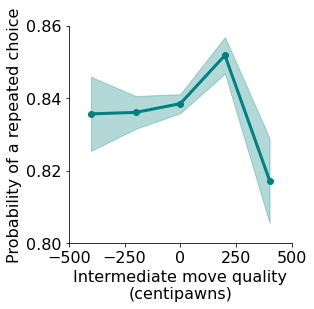

In [71]:
# Plot
fig, ax = plt.subplots(figsize=(4,4))

ax.errorbar(eval_range+100, [m for m,s in means], marker='o', color='teal', lw=3)
ax.fill_between(eval_range+100, [m-s for m,s in means], [m+s for m,s in means], color='teal', alpha=0.3)
ax.set_ylabel('Probability of a repeated choice')
ax.set_xlabel('Intermediate move quality\n(centipawns)')
ax.set_xticks([-500,-250,0,250,500])
ax.set_yticks([0.80,0.82,0.84,0.86])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig('RL_intermediate.png', format='png', dpi=1000,bbox_inches = 'tight')